# 04 · Interpretability Analysis

**Central thesis contribution.** Earlier theses on Dutch energy demand forecasting (Susan 2022, Duaa 2023, Ruben 2024) consistently identified multicollinearity among climate and economic predictors as a challenge, and Ruben (2024) explicitly recommended PCA and dimensionality reduction as future work. This notebook provides the systematic answer: quantitative evidence for how each of the four multicollinearity-handling strategies compares on *interpretability*, not just accuracy.

| Hypothesis | Question |
|---|---|
| **H1** | Do Ridge and Elastic Net yield more stable coefficients than correlation filtering, at competitive forecast accuracy? |
| **H2** | Does correlation filtering discard predictors that carry residual explanatory power (information loss)? |
| **H3** | Are SHAP-based predictor importance rankings consistent across multicollinearity-handling strategies? |

**Structure:**
1. **§1 Coefficient Stability** — 5-fold rolling CV on training data: Coefficient of Variation (CV = std/|mean|) and sign consistency per predictor × strategy
2. **§2 SHAP Analysis** — XGBoost on Stage-1 test residuals; SHAP values quantify which predictors each strategy failed to capture
3. **§3 Hypothesis Tests** — Quantitative answers to H1, H2, and H3 (SHAP rank correlation across strategies)

**Inputs:** `data/strategy_*_{train,test}.csv`, `data/sarimax_mape_table.csv`, strategy param JSON files  
**Outputs:** `data/interpretability_coef_stability.csv`, `data/interpretability_shap_summary.csv`, `data/interpretability_h1_summary.csv`, `data/interpretability_h2_info_loss.csv`, `data/interpretability_h3_shap_consistency.csv`, `data/interpretability_h3_summary.csv`, plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

def _conda_install(pkg):
    import subprocess, sys
    conda_exe = os.path.join(os.path.dirname(sys.executable), '..', 'bin', 'conda')
    conda_exe = os.path.normpath(conda_exe)
    if not os.path.exists(conda_exe):
        conda_exe = 'conda'
    subprocess.check_call([conda_exe, 'install', '-y', '-q', '-c', 'conda-forge', pkg])

try:
    import shap
    print(f'shap {shap.__version__}')
except ImportError:
    _conda_install('shap')
    import shap
    print(f'shap {shap.__version__} (just installed)')

try:
    import xgboost as xgb
    print(f'xgboost {xgb.__version__}')
except ImportError:
    _conda_install('xgboost')
    import xgboost as xgb
    print(f'xgboost {xgb.__version__} (just installed)')

os.makedirs('plots', exist_ok=True)
print('All imports OK')

shap 0.48.0
xgboost 3.2.0
All imports OK


In [2]:
DATA_DIR = 'data'
PLOT_DIR = 'plots'
N_CV_SPLITS = 10

# Load hyperparameters from notebook 02
with open(f'{DATA_DIR}/strategy_ridge_params.json') as f:
    ridge_params = json.load(f)
with open(f'{DATA_DIR}/strategy_elasticnet_params.json') as f:
    enet_params = json.load(f)

RIDGE_ALPHA = ridge_params['lambda']
ENET_L1     = enet_params['l1_ratio']
ENET_ALPHA  = enet_params['alpha']

# Load train/test demand targets
train_df = pd.read_csv(f'{DATA_DIR}/train.csv', parse_dates=['date'])
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv',  parse_dates=['date'])
y_train  = train_df['demand_MW'].values
y_test   = test_df['demand_MW'].values

# Load strategy feature matrices (pre-scaled, from notebook 02)
def load_split(strategy, split):
    df = pd.read_csv(f'{DATA_DIR}/strategy_{strategy}_{split}.csv', parse_dates=['date'])
    return df.drop(columns=['date'])

s1_tr = load_split('filtered',   'train');  s1_te = load_split('filtered',   'test')
s2_tr = load_split('pca',        'train');  s2_te = load_split('pca',        'test')
s3_tr = load_split('ridge',      'train');  s3_te = load_split('ridge',      'test')
s4_tr = load_split('elasticnet', 'train');  s4_te = load_split('elasticnet', 'test')

s1_cols = list(s1_tr.columns)
s3_cols = list(s3_tr.columns)  # all 18 features (Ridge uses all)
s4_cols = list(s4_tr.columns)

# Features removed by each strategy
filtered_out_s1 = sorted(set(s3_cols) - set(s1_cols))
zeroed_by_enet  = enet_params['zeroed_features']

print(f'Train: {len(y_train):,} days ({train_df.date.min().date()} to {train_df.date.max().date()})')
print(f'Test : {len(y_test):,}  days ({test_df.date.min().date()} to {test_df.date.max().date()})')
print(f'Features — S1(Filter): {len(s1_cols)} | S3(Ridge): {len(s3_cols)} | S4(ElasNet): {len(s4_cols)}')
print(f'Filtered out by S1     : {filtered_out_s1}')
print(f'Zeroed by ElasticNet   : {zeroed_by_enet}')
print(f'Ridge alpha={RIDGE_ALPHA} | ElasNet l1_ratio={ENET_L1}, alpha={ENET_ALPHA}')

Train: 4,281 days (2009-01-01 to 2020-09-20)
Test : 919  days (2023-03-27 to 2025-09-30)
Features — S1(Filter): 16 | S3(Ridge): 18 | S4(ElasNet): 12
Filtered out by S1     : ['population', 'sunshine_h']
Zeroed by ElasticNet   : ['humidity_pct', 'cloudiness', 'gdp_mln_eur', 'wind_energy_gwh', 'sunshine_h', 'precip_mm']
Ridge alpha=100.0 | ElasNet l1_ratio=1.0, alpha=0.01


---
## §1 Coefficient Stability — 10-Fold Rolling Cross-Validation

We use `TimeSeriesSplit(n_splits=10)` on the training data (4281 days). For each fold, we refit the Stage-1 regression for strategies 1, 3, and 4 (OLS, Ridge, ElasticNet) using the fixed hyperparameters tuned in notebook 02. Strategy 2 (PCA) is excluded because its component coefficients are not interpretable in the original feature space.

**Metrics:**
- **CV (Coefficient of Variation):** `std(coef) / |mean(coef)|` across 10 folds — **lower = more stable**
- **Sign consistency:** fraction of folds where the coefficient's sign matches the overall mean sign — **1.0 = always consistent**
- **Absolute contribution std:** `std(coef) × std(feature)` — measures fold-to-fold prediction impact of coefficient instability in MW, removing the denominator-bias in CV when Ridge shrinks coefficients toward zero

> **Expected result (H1):** Ridge and ElasticNet should show lower CV than Filter/OLS for collinear predictors (temp_c, pressure_hpa, global_rad), because L2/L1 regularisation shrinks coefficients toward a stable solution rather than amplifying multicollinearity.

In [3]:
# Rolling CV — refit S1/S3/S4 per fold and record coefficients
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

coef_folds = {'Filter': [], 'Ridge': [], 'ElasticNet': []}
X_s1 = s1_tr.values
X_s3 = s3_tr.values
X_s4 = s4_tr.values

for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_s3)):
    y_fold = y_train[tr_idx]

    # Strategy 1: OLS on filtered feature set
    ols = LinearRegression().fit(X_s1[tr_idx], y_fold)
    coef_folds['Filter'].append(dict(zip(s1_cols, ols.coef_)))

    # Strategy 3: Ridge on all features
    ridge = Ridge(alpha=RIDGE_ALPHA).fit(X_s3[tr_idx], y_fold)
    coef_folds['Ridge'].append(dict(zip(s3_cols, ridge.coef_)))

    # Strategy 4: ElasticNet (l1_ratio=1 = Lasso)
    enet = ElasticNet(l1_ratio=ENET_L1, alpha=ENET_ALPHA, max_iter=5000)
    enet.fit(X_s4[tr_idx], y_fold)
    coef_folds['ElasticNet'].append(dict(zip(s4_cols, enet.coef_)))

    n_tr, n_va = len(tr_idx), len(va_idx)
    print(f'  Fold {fold+1}/{N_CV_SPLITS}: train={n_tr:,}, val={n_va:,}')

print('CV complete.')

  Fold 1/10: train=391, val=389
  Fold 2/10: train=780, val=389
  Fold 3/10: train=1,169, val=389
  Fold 4/10: train=1,558, val=389
  Fold 5/10: train=1,947, val=389
  Fold 6/10: train=2,336, val=389
  Fold 7/10: train=2,725, val=389
  Fold 8/10: train=3,114, val=389
  Fold 9/10: train=3,503, val=389
  Fold 10/10: train=3,892, val=389
CV complete.


In [4]:
def stability_metrics(coef_list, feature_universe):
    '''Compute CV and sign consistency for a list of fold coefficient dicts.'''
    # Build a DataFrame: rows=folds, cols=features (NaN if feature absent in strategy)
    df = pd.DataFrame(
        [{f: d.get(f, np.nan) for f in feature_universe} for d in coef_list]
    )
    mean_c = df.mean()
    std_c  = df.std()
    # CV = std / |mean|, capped at 5 to avoid div-by-zero inflation
    cv = (std_c / mean_c.abs()).clip(upper=5.0)
    # Sign consistency: fraction of folds matching sign of cross-fold mean
    sign_cons = pd.Series({
        feat: float((np.sign(df[feat].dropna()) == np.sign(mean_c[feat])).mean())
        for feat in feature_universe
        if feat in df.columns and mean_c[feat] != 0
    })
    return mean_c, std_c, cv, sign_cons

# Feature standard deviations from training data (all 18 features via s3_tr)
# Used to compute abs_contrib_std = std(coef) * std(feature) — scale-invariant instability
std_feat_train = s3_tr.std()

# All unique features across the three interpretable strategies
all_feats = sorted(set(s1_cols) | set(s3_cols) | set(s4_cols))

mean_s1, std_s1, cv_s1, sign_s1 = stability_metrics(coef_folds['Filter'],     all_feats)
mean_s3, std_s3, cv_s3, sign_s3 = stability_metrics(coef_folds['Ridge'],      all_feats)
mean_s4, std_s4, cv_s4, sign_s4 = stability_metrics(coef_folds['ElasticNet'], all_feats)

# Absolute contribution std: std(coef) * std(feature_in_training)
# Measures how much fold-to-fold coefficient variation propagates to predictions (in MW units)
# Removes the denominator-bias in CV where Ridge shrinkage inflates CV by reducing |mean|
abs_contrib_s1 = (std_s1 * std_feat_train.reindex(all_feats))
abs_contrib_s3 = (std_s3 * std_feat_train.reindex(all_feats))
abs_contrib_s4 = (std_s4 * std_feat_train.reindex(all_feats))

abs_contrib_hm = pd.DataFrame({
    'Filter (OLS)': abs_contrib_s1,
    'Ridge':        abs_contrib_s3,
    'ElasticNet':   abs_contrib_s4,
}).reindex(all_feats)

# Build heatmap DataFrames (rows=features, cols=strategies)
cv_hm = pd.DataFrame({
    'Filter (OLS)': cv_s1,
    'Ridge':        cv_s3,
    'ElasticNet':   cv_s4,
}).reindex(all_feats)

sign_hm = pd.DataFrame({
    'Filter (OLS)': sign_s1,
    'Ridge':        sign_s3,
    'ElasticNet':   sign_s4,
}).reindex(all_feats)

print('Median CV across features (lower = more stable):')
print(cv_hm.median().round(3))
print('\nMean sign consistency (higher = more consistent):')
print(sign_hm.mean().round(3))
print('\nMedian abs_contrib_std (MW; lower = less prediction-impact instability):')
print(abs_contrib_hm.median().round(2))

Median CV across features (lower = more stable):
Filter (OLS)    0.864
Ridge           0.678
ElasticNet      0.674
dtype: float64

Mean sign consistency (higher = more consistent):
Filter (OLS)    0.838
Ridge           0.861
ElasticNet      0.950
dtype: float64

Median abs_contrib_std (MW; lower = less prediction-impact instability):
Filter (OLS)    39.51
Ridge           48.52
ElasticNet      42.61
dtype: float64


=== Coefficient Stability by Feature Group (median CV) ===
Group            N    Filter    Ridge  ElasNet  Ridge vs Filter
-----------------------------------------------------------------
Behavioral       4     0.400    0.389    0.420  Ridge more stable (Δ=+0.011)
Climate          7     0.436    0.505    0.367  Filter more stable (Δ=-0.069)
Economic         6     2.860    1.488    0.748  Ridge more stable (Δ=+1.372)

Saved: data/interpretability_h1_stratified.csv

=== Absolute Contribution Std by Feature Group (median, MW) ===
Group            Filter    Ridge  ElasNet  Ridge vs Filter
----------------------------------------------------------
Behavioral        22.76    67.24    27.24  Filter lower
Climate           34.73    28.26    38.36  Ridge lower
Economic         439.87    70.96   272.82  Ridge lower

Saved: data/interpretability_h1_abs_stability.csv


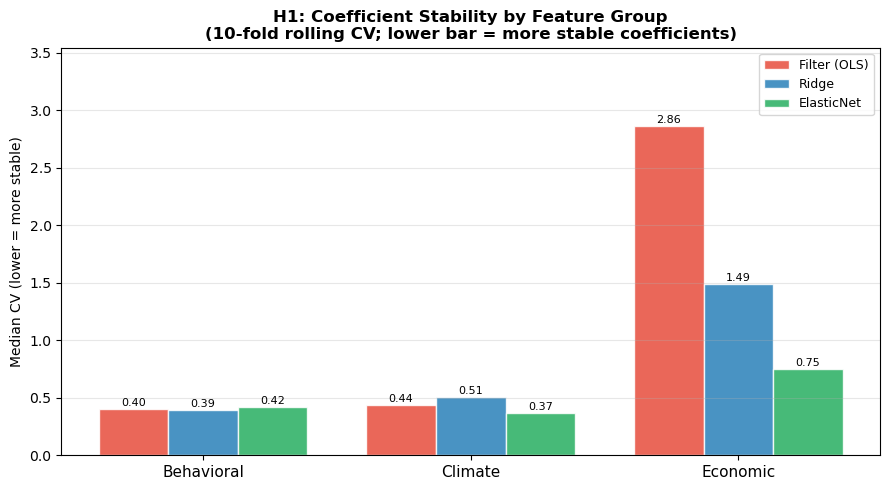

Saved: plots/interpretability_h1_stratified.png


In [5]:
# ── Feature-stratified coefficient stability analysis ─────────────────────
# H1 predicts Ridge is more stable. Aggregate tests mask feature-type structure:
# regularisation benefits vary between behavioral predictors (calendar/dummy features)
# and climate/economic predictors where correlation filtering removes collinear partners.

FEAT_GROUPS = {
    'Behavioral': ['day_of_week', 'is_holiday', 'is_weekend', 'month'],
    'Climate':    ['cloudiness', 'global_rad', 'humidity_pct', 'nao',
                   'precip_mm', 'pressure_hpa', 'temp_c'],
    'Economic':   ['gdp_mln_eur', 'population', 'price_eur_kwh',
                   'solar_energy_gwh', 'wind_energy_gwh', 'wind_ms'],
}

print('=== Coefficient Stability by Feature Group (median CV) ===')
print(f'{"Group":<14} {"N":>3}  {"Filter":>8} {"Ridge":>8} {"ElasNet":>8}  {"Ridge vs Filter"}')
print('-' * 65)

stratified_rows = []
for group_name, feats in FEAT_GROUPS.items():
    valid = [f for f in feats if f in cv_hm.index]
    cv_f = cv_hm.loc[valid, 'Filter (OLS)'].dropna()
    cv_r = cv_hm.loc[valid, 'Ridge'].dropna()
    cv_e = cv_hm.loc[valid, 'ElasticNet'].dropna()
    med_f = cv_f.median()
    med_r = cv_r.median()
    med_e = cv_e.median()
    direction = 'Ridge more stable' if med_r < med_f else 'Filter more stable'
    delta = med_f - med_r  # positive = Ridge wins
    print(f'{group_name:<14} {len(valid):>3}  {med_f:>8.3f} {med_r:>8.3f} {med_e:>8.3f}  '
          f'{direction} (Δ={delta:+.3f})')
    stratified_rows.append({
        'group': group_name,
        'n_features': len(valid),
        'filter_median_cv': round(float(med_f), 4),
        'ridge_median_cv': round(float(med_r), 4),
        'elasticnet_median_cv': round(float(med_e), 4),
        'delta_filter_minus_ridge': round(float(delta), 4),
        'ridge_more_stable': bool(med_r < med_f),
    })

stratified_df = pd.DataFrame(stratified_rows)
stratified_df.to_csv(f'{DATA_DIR}/interpretability_h1_stratified.csv', index=False)
print(f'\nSaved: {DATA_DIR}/interpretability_h1_stratified.csv')

# ── Abs_contrib_std by group ───────────────────────────────────────────────
print('\n=== Absolute Contribution Std by Feature Group (median, MW) ===')
print(f'{"Group":<14} {"Filter":>8} {"Ridge":>8} {"ElasNet":>8}  {"Ridge vs Filter"}')
print('-' * 58)
abs_contrib_rows = []
for group_name, feats in FEAT_GROUPS.items():
    valid = [f for f in feats if f in abs_contrib_hm.index]
    ac_f = abs_contrib_hm.loc[valid, 'Filter (OLS)'].dropna()
    ac_r = abs_contrib_hm.loc[valid, 'Ridge'].dropna()
    ac_e = abs_contrib_hm.loc[valid, 'ElasticNet'].dropna()
    med_f, med_r, med_e = ac_f.median(), ac_r.median(), ac_e.median()
    direction = 'Ridge lower' if med_r < med_f else 'Filter lower'
    print(f'{group_name:<14} {med_f:>8.2f} {med_r:>8.2f} {med_e:>8.2f}  {direction}')
    abs_contrib_rows.append({
        'group': group_name,
        'filter_median_abs_contrib_mw': round(float(med_f), 4),
        'ridge_median_abs_contrib_mw': round(float(med_r), 4),
        'elasticnet_median_abs_contrib_mw': round(float(med_e), 4),
    })

abs_stability_df = pd.DataFrame(abs_contrib_rows)
abs_stability_df.to_csv(f'{DATA_DIR}/interpretability_h1_abs_stability.csv', index=False)
print(f'\nSaved: {DATA_DIR}/interpretability_h1_abs_stability.csv')

# ── Grouped bar chart: median CV by feature group × strategy ──────────────
fig, ax = plt.subplots(figsize=(9, 5))
groups   = list(FEAT_GROUPS.keys())
x        = np.arange(len(groups))
width    = 0.26
colors_s = {'Filter (OLS)': '#e74c3c', 'Ridge': '#2980b9', 'ElasticNet': '#27ae60'}
strats   = ['Filter (OLS)', 'Ridge', 'ElasticNet']

for i, strat in enumerate(strats):
    medians = []
    for group_name, feats in FEAT_GROUPS.items():
        valid = [f for f in feats if f in cv_hm.index]
        vals = cv_hm.loc[valid, strat].dropna()
        medians.append(vals.median())
    bars = ax.bar(x + (i - 1) * width, medians, width, label=strat,
                  color=colors_s[strat], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.set_ylabel('Median CV (lower = more stable)', fontsize=10)
ax.set_title('H1: Coefficient Stability by Feature Group\n'
             '(10-fold rolling CV; lower bar = more stable coefficients)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/interpretability_h1_stratified.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_h1_stratified.png')

### H1 — Formal Statistical Tests for Coefficient Stability

The per-feature CV comparison above shows a small aggregate difference between strategies. A formal test is needed to determine if the difference is statistically meaningful, not noise.

**Test: Wilcoxon signed-rank test** on paired per-feature CV differences, using pairwise masks so each comparison uses the maximum available features (Filter vs Ridge: N=16; Filter vs ElasticNet: N=12; Ridge vs ElasticNet: N=12).
- H₀: median difference in CV between strategies = 0
- p < 0.05 → strategies differ significantly in coefficient stability

We also report a **bootstrap 95% CI** on the median CV(Filter) − CV(Ridge) difference to quantify uncertainty.

In [6]:
from scipy.stats import wilcoxon

# Pairwise masks — use the maximum available features for each comparison.
# The original three-way intersection (N=11) was artificially small because
# ElasticNet zeros 6 features, penalising the Filter-vs-Ridge comparison.
# Using pairwise masks gives N=16 for Filter vs Ridge (45% more power).
mask_f_r = cv_s1.notna() & cv_s3.notna()   # Filter vs Ridge: 16 features
mask_f_e = cv_s1.notna() & cv_s4.notna()   # Filter vs ElasticNet: 12 features
mask_r_e = cv_s3.notna() & cv_s4.notna()   # Ridge vs ElasticNet: 12 features

print('Feature counts per pair (pairwise masks, no ElasticNet intersection penalty):')
print(f'  Filter vs Ridge:       N = {mask_f_r.sum()} features')
print(f'  Filter vs ElasticNet:  N = {mask_f_e.sum()} features')
print(f'  Ridge  vs ElasticNet:  N = {mask_r_e.sum()} features')

pairs_h1 = [
    ('Filter vs Ridge',      cv_s1[mask_f_r].values, cv_s3[mask_f_r].values),
    ('Filter vs ElasticNet', cv_s1[mask_f_e].values, cv_s4[mask_f_e].values),
    ('Ridge vs ElasticNet',  cv_s3[mask_r_e].values, cv_s4[mask_r_e].values),
]

print('\nWilcoxon signed-rank test (H₀: no difference in CV between strategies)')
print('  Positive W stat → first strategy has higher CV (less stable)')
print()
h1_test_rows = []
for label, cv_a, cv_b in pairs_h1:
    diff = cv_a - cv_b
    if np.all(diff == 0):
        print(f'  {label}: all differences = 0, skipping')
        continue
    stat, p = wilcoxon(cv_a, cv_b, alternative='two-sided')
    med_diff = np.median(diff)
    n = len(cv_a)
    print(f'  {label} (N={n}): W={stat:.1f}, p={p:.4f}, median CV diff={med_diff:+.4f} '
          f'({"*sig*" if p < 0.05 else "n.s."})')
    h1_test_rows.append({
        'comparison': label,
        'n_features': n,
        'wilcoxon_stat': round(stat, 2),
        'p_value': round(p, 4),
        'median_cv_difference': round(float(med_diff), 4),
        'significant_5pct': bool(p < 0.05),
    })

# ── Bootstrap 95% CI on median CV difference (Filter vs Ridge, N=16) ───────
cv_filter_fr = cv_s1[mask_f_r].values.astype(float)
cv_ridge_fr  = cv_s3[mask_f_r].values.astype(float)
n_fr = len(cv_filter_fr)

np.random.seed(42)
N_BOOT = 2000
boot_diffs = []
for _ in range(N_BOOT):
    idx = np.random.choice(n_fr, n_fr, replace=True)
    boot_diffs.append(np.median(cv_filter_fr[idx] - cv_ridge_fr[idx]))

ci_lo, ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
obs_diff = np.median(cv_filter_fr - cv_ridge_fr)
print(f'\nBootstrap 95% CI on median CV(Filter) - CV(Ridge) [N={n_fr} features]:')
print(f'  Observed difference : {obs_diff:+.4f}')
print(f'  95% CI              : [{ci_lo:+.4f}, {ci_hi:+.4f}]')
print(f'  CI excludes 0       : {not (ci_lo <= 0 <= ci_hi)}')
if not (ci_lo <= 0 <= ci_hi):
    print('  → Significant: Filter and Ridge differ in coefficient stability')
else:
    print('  → Not significant: CV difference is within sampling uncertainty')

h1_test_rows.append({
    'comparison': 'Filter vs Ridge (bootstrap)',
    'n_features': n_fr,
    'wilcoxon_stat': None,
    'p_value': None,
    'median_cv_difference': round(float(obs_diff), 4),
    'significant_5pct': not (ci_lo <= 0 <= ci_hi),
    'bootstrap_ci_lo': round(float(ci_lo), 4),
    'bootstrap_ci_hi': round(float(ci_hi), 4),
})

h1_tests_df = pd.DataFrame(h1_test_rows)
h1_tests_df.to_csv(f'{DATA_DIR}/interpretability_h1_tests.csv', index=False)
print(f'\nSaved: {DATA_DIR}/interpretability_h1_tests.csv')

Feature counts per pair (pairwise masks, no ElasticNet intersection penalty):
  Filter vs Ridge:       N = 16 features
  Filter vs ElasticNet:  N = 11 features
  Ridge  vs ElasticNet:  N = 12 features

Wilcoxon signed-rank test (H₀: no difference in CV between strategies)
  Positive W stat → first strategy has higher CV (less stable)

  Filter vs Ridge (N=16): W=56.0, p=0.8203, median CV diff=+0.0081 (n.s.)
  Filter vs ElasticNet (N=11): W=25.0, p=0.5195, median CV diff=+0.0068 (n.s.)
  Ridge vs ElasticNet (N=12): W=22.0, p=0.3652, median CV diff=+0.0204 (n.s.)

Bootstrap 95% CI on median CV(Filter) - CV(Ridge) [N=16 features]:
  Observed difference : +0.0081
  95% CI              : [-0.2448, +0.2629]
  CI excludes 0       : False
  → Not significant: CV difference is within sampling uncertainty

Saved: data/interpretability_h1_tests.csv


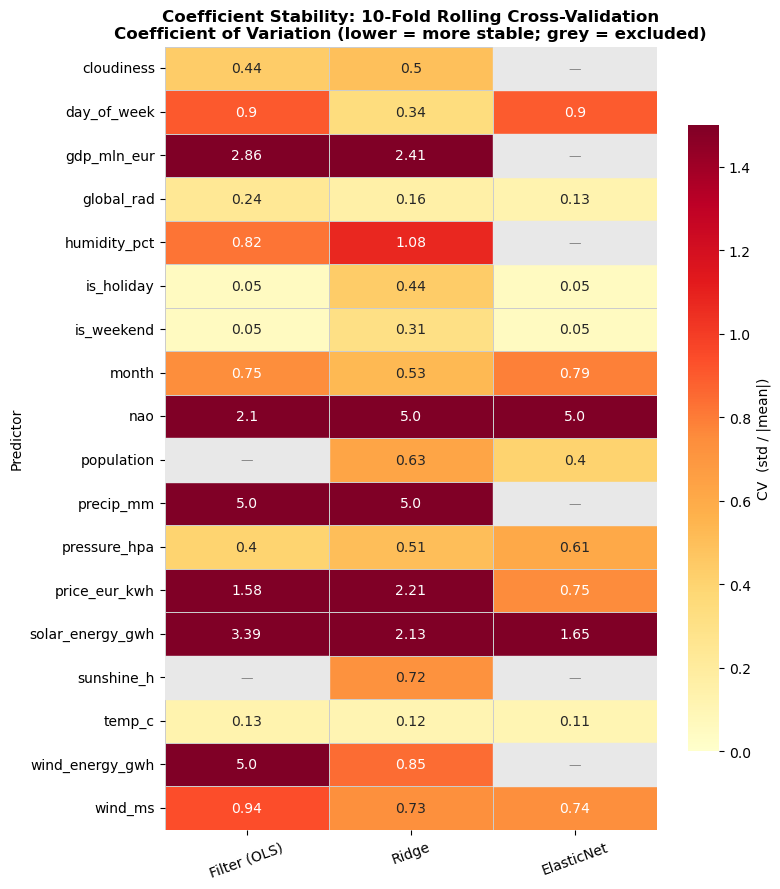

Saved: plots/interpretability_coef_stability.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 9))

cv_plot = cv_hm.astype(float)
cv_plot_display = cv_plot.fillna(-0.1)
mask_na = cv_plot.isna()

sns.heatmap(
    cv_plot_display,
    ax=ax,
    cmap='YlOrRd',
    vmin=0, vmax=1.5,
    annot=cv_plot.round(2).fillna('—'),
    fmt='',
    linewidths=0.5,
    linecolor='#cccccc',
    cbar_kws={'label': 'CV  (std / |mean|)', 'shrink': 0.8},
    mask=mask_na
)
for i, feat in enumerate(all_feats):
    for j, strat in enumerate(['Filter (OLS)', 'Ridge', 'ElasticNet']):
        if pd.isna(cv_hm.loc[feat, strat]):
            ax.add_patch(mpatches.Rectangle((j, i), 1, 1, fill=True,
                          color='#e8e8e8', zorder=2))
            ax.text(j + 0.5, i + 0.5, '—', ha='center', va='center',
                     fontsize=9, color='#888888')
ax.set_title('Coefficient Stability: 10-Fold Rolling Cross-Validation\n'
             'Coefficient of Variation (lower = more stable; grey = excluded)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Predictor')
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/interpretability_coef_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_coef_stability.png')

---
## §2 SHAP Analysis on Stage-1 Test Residuals

**Approach:** For each strategy, we fit the Stage-1 regression on the full training set and compute out-of-sample residuals on the test set:
$$\text{residual}_{i} = y_i^{\text{demand}} - \hat{y}_i^{\text{Stage-1}}$$

We then fit an XGBoost regressor on these residuals using **all 18 original (scaled) features** — including those that may have been excluded by a given strategy. This lets us ask: *which predictors explain what the Stage-1 model missed?*

**Key question for H2:** Do the features removed by correlation filtering (population, sunshine_h) appear as important SHAP contributors in the Filter strategy's residuals? If yes, filtering discarded useful information.

**Note on PCA:** Strategy 2 (PCA) is included for completeness. Its Stage-1 compresses 9 continuous features into 9 principal components, so its residuals reflect information that PCA failed to reconstruct — analogous to reconstruction error.

In [8]:
# Fit Stage-1 on full training set for each strategy
stage1_models = {
    'Filter':     LinearRegression().fit(s1_tr.values, y_train),
    'PCA':        LinearRegression().fit(s2_tr.values, y_train),
    'Ridge':      Ridge(alpha=RIDGE_ALPHA).fit(s3_tr.values, y_train),
    'ElasticNet': ElasticNet(l1_ratio=ENET_L1, alpha=ENET_ALPHA, max_iter=5000).fit(s4_tr.values, y_train),
}
test_inputs = {
    'Filter':     s1_te.values,
    'PCA':        s2_te.values,
    'Ridge':      s3_te.values,
    'ElasticNet': s4_te.values,
}

# Compute Stage-1 out-of-sample predictions and residuals
stage1_pred   = {}
stage1_resid  = {}
for name, model in stage1_models.items():
    pred = model.predict(test_inputs[name])
    stage1_pred[name]  = pred
    stage1_resid[name] = y_test - pred

# Summary statistics
print(f'{"Strategy":<12}  {"RMSE (MW)":>10}  {"MAE (MW)":>9}  {"R2":>7}')
print('-' * 42)
for name, resid in stage1_resid.items():
    rmse = np.sqrt(np.mean(resid**2))
    mae  = np.mean(np.abs(resid))
    r2   = 1 - np.var(resid) / np.var(y_test)
    print(f'{name:<12}  {rmse:>10.0f}  {mae:>9.0f}  {r2:>7.4f}')

Strategy       RMSE (MW)   MAE (MW)       R2
------------------------------------------
Filter               778        633   0.6509
PCA                 1286       1135   0.6566
Ridge               1012        764   0.6518
ElasticNet          1072        820   0.6323


In [9]:
# SHAP: use ALL original features as XGBoost input (s3_te = Ridge test = all 18 features)
# This allows SHAP to attribute residuals to ANY feature, including filtered/zeroed ones
X_shap = s3_te.copy()  # DataFrame with proper column names

shap_values  = {}
xgb_r2       = {}

strategy_names  = ['Filter', 'PCA', 'Ridge', 'ElasticNet']
strategy_labels = [
    'Strategy 1: Filter (OLS)',
    'Strategy 2: PCA',
    'Strategy 3: Ridge',
    'Strategy 4: ElasticNet',
]

import builtins

def _shap_tree_explainer(xgb_model):
    """Workaround for XGBoost 2.x / SHAP TreeExplainer incompatibility.

    XGBoost 2.x serialises base_score as '[value]' (e.g. '[-1.14E1]') in its
    internal JSON. SHAP calls float() on that string directly and crashes.
    We temporarily replace builtins.float to strip the brackets, then restore it.
    """
    _orig = builtins.float
    def _float(x):
        if isinstance(x, str) and x.startswith('[') and x.endswith(']'):
            return _orig(x[1:-1])
        return _orig(x)
    builtins.float = _float
    try:
        explainer = shap.TreeExplainer(xgb_model.get_booster())
    finally:
        builtins.float = _orig
    return explainer

for name in strategy_names:
    resid = stage1_resid[name]

    xgb_model = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    xgb_model.fit(X_shap, resid)

    explainer   = _shap_tree_explainer(xgb_model)
    sv          = explainer.shap_values(X_shap)
    shap_values[name] = sv

    pred_resid = xgb_model.predict(X_shap)
    r2_xgb = 1 - np.var(resid - pred_resid) / np.var(resid)
    xgb_r2[name] = r2_xgb
    print(f'{name:<12}: XGB R2 on residuals = {r2_xgb:.4f}  |  mean|SHAP| = {np.abs(sv).mean():.1f} MW')

Filter      : XGB R2 on residuals = 0.9630  |  mean|SHAP| = 58.5 MW
PCA         : XGB R2 on residuals = 0.9606  |  mean|SHAP| = 59.3 MW
Ridge       : XGB R2 on residuals = 0.9628  |  mean|SHAP| = 55.1 MW
ElasticNet  : XGB R2 on residuals = 0.9678  |  mean|SHAP| = 60.2 MW


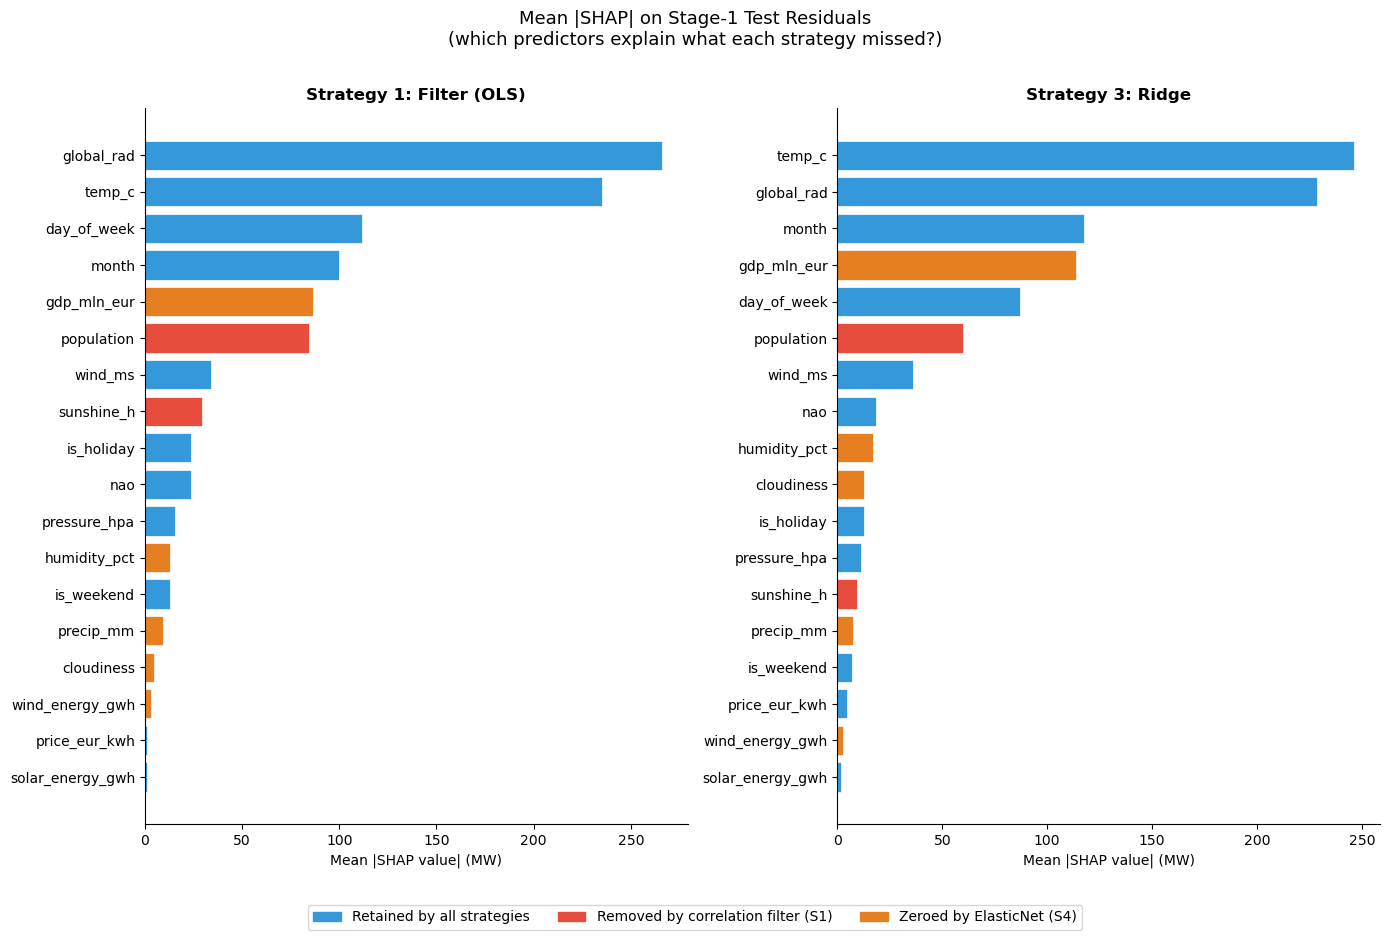

Saved: plots/interpretability_shap_bar.png


In [10]:
# SHAP bar plots: mean |SHAP| per feature for Filter and Ridge (primary contrast)
# Red bars = features filtered out by Strategy 1 (correlation filter)
# Orange bars = features zeroed by ElasticNet

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

names_to_plot  = ['Filter', 'Ridge']
labels_to_plot = ['Strategy 1: Filter (OLS)', 'Strategy 3: Ridge']

for ax, name, label in zip(axes, names_to_plot, labels_to_plot):
    mean_shap = pd.Series(
        np.abs(shap_values[name]).mean(axis=0),
        index=s3_cols
    ).sort_values(ascending=True)

    colors = []
    for feat in mean_shap.index:
        if feat in filtered_out_s1:
            colors.append('#e74c3c')
        elif feat in zeroed_by_enet:
            colors.append('#e67e22')
        else:
            colors.append('#3498db')

    ax.barh(range(len(mean_shap)), mean_shap.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(mean_shap)))
    ax.set_yticklabels(mean_shap.index, fontsize=10)
    ax.set_xlabel('Mean |SHAP value| (MW)', fontsize=10)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#3498db', label='Retained by all strategies'),
    mpatches.Patch(color='#e74c3c', label='Removed by correlation filter (S1)'),
    mpatches.Patch(color='#e67e22', label='Zeroed by ElasticNet (S4)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02), frameon=True)

plt.suptitle('Mean |SHAP| on Stage-1 Test Residuals\n(which predictors explain what each strategy missed?)',
             fontsize=13, y=1.01)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f'{PLOT_DIR}/interpretability_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_shap_bar.png')

In [11]:
# SHAP beeswarm plots (individual figures — shap.summary_plot creates its own figure)
for name, label in zip(strategy_names, strategy_labels):
    shap.summary_plot(
        shap_values[name], X_shap,
        plot_type='dot', max_display=18, show=False
    )
    plt.title(f'SHAP Beeswarm — {label}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f'{PLOT_DIR}/interpretability_shap_beeswarm_{name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Saved: {fname}')

Saved: plots/interpretability_shap_beeswarm_filter.png
Saved: plots/interpretability_shap_beeswarm_pca.png
Saved: plots/interpretability_shap_beeswarm_ridge.png
Saved: plots/interpretability_shap_beeswarm_elasticnet.png


In [12]:
# H2 evidence: information loss from correlation filtering
# Measure: for S1 (Filter), what fraction of total |SHAP| is attributable to filtered-out features?
# Compare same measure for S3 (Ridge) — Ridge includes those features, so they should have lower residual SHAP

print('=== H2: Information Loss from Correlation Filtering ===')
print(f'Features removed by S1 correlation filter: {filtered_out_s1}')
print()

info_loss_rows = []
for name in ['Filter', 'Ridge', 'ElasticNet']:
    mean_shap = pd.Series(np.abs(shap_values[name]).mean(axis=0), index=s3_cols)
    total_shap    = mean_shap.sum()
    # SHAP for features removed by S1
    shap_filtered = mean_shap[mean_shap.index.isin(filtered_out_s1)].sum()
    # SHAP for features zeroed by ElasticNet
    shap_enet_z   = mean_shap[mean_shap.index.isin(zeroed_by_enet)].sum()
    pct_filtered  = 100 * shap_filtered / total_shap
    pct_enet_z    = 100 * shap_enet_z   / total_shap

    info_loss_rows.append({
        'Strategy': name,
        'Total |SHAP| (MW)': round(total_shap, 2),
        '|SHAP| for S1-filtered features (MW)': round(shap_filtered, 2),
        '% attributed to S1-filtered': round(pct_filtered, 2),
        '|SHAP| for ElasNet-zeroed (MW)': round(shap_enet_z, 2),
        '% attributed to ElasNet-zeroed': round(pct_enet_z, 2),
        'XGB R2 on residuals': round(xgb_r2[name], 4),
    })
    print(f'{name:<12}: total|SHAP|={total_shap:.1f} MW  |  '
          f'S1-filtered features = {shap_filtered:.1f} MW ({pct_filtered:.1f}%)  |  '
          f'XGB R2 = {xgb_r2[name]:.4f}')

info_loss_df = pd.DataFrame(info_loss_rows)
print()
print('Interpretation:')
filt_pct_filter = info_loss_df.loc[info_loss_df['Strategy']=='Filter', '% attributed to S1-filtered'].values[0]
filt_pct_ridge  = info_loss_df.loc[info_loss_df['Strategy']=='Ridge',  '% attributed to S1-filtered'].values[0]
if filt_pct_filter > filt_pct_ridge:
    print(f'  H2 SUPPORTED: S1-filtered features explain {filt_pct_filter:.1f}% of Filter residuals '
          f'vs {filt_pct_ridge:.1f}% of Ridge residuals.')
    print(f'  This {filt_pct_filter - filt_pct_ridge:.1f}pp gap quantifies the information discarded by correlation filtering.')
else:
    print(f'  H2 NOT SUPPORTED: S1-filtered features explain {filt_pct_filter:.1f}% of Filter residuals '
          f'vs {filt_pct_ridge:.1f}% of Ridge residuals (no clear information loss).')

=== H2: Information Loss from Correlation Filtering ===
Features removed by S1 correlation filter: ['population', 'sunshine_h']

Filter      : total|SHAP|=1053.5 MW  |  S1-filtered features = 113.4 MW (10.8%)  |  XGB R2 = 0.9630
Ridge       : total|SHAP|=992.3 MW  |  S1-filtered features = 69.0 MW (7.0%)  |  XGB R2 = 0.9628
ElasticNet  : total|SHAP|=1084.1 MW  |  S1-filtered features = 106.5 MW (9.8%)  |  XGB R2 = 0.9678

Interpretation:
  H2 SUPPORTED: S1-filtered features explain 10.8% of Filter residuals vs 7.0% of Ridge residuals.
  This 3.8pp gap quantifies the information discarded by correlation filtering.


### H2 — Bootstrap Confidence Interval on Information Loss Gap

The observed gap (Filter residuals attribute 10.8% of SHAP to filtered features vs 7.0% for Ridge = **3.8pp**) needs a confidence interval to confirm it is not due to sampling variation in the SHAP computation.

**Method:** Bootstrap the test set observations 2000 times (row-level resampling of the pre-computed SHAP matrices). For each resample, recompute the information loss gap. Report 95% CI.

If the CI excludes zero, the 3.8pp gap is statistically meaningful.

=== H2: Bootstrap CI on Information Loss Gap ===
Filtered-out features: ['population', 'sunshine_h']
Observed gap          : +3.81 pp (Filter has more residual SHAP in filtered features)
Bootstrap 95% CI      : [+3.38, +4.24] pp
CI excludes 0         : True

  → H2 CONFIRMED: The 3.8pp information loss gap is statistically significant.
     Correlation filtering discards explanatory power that Ridge retains.

Saved: data/interpretability_h2_bootstrap.csv


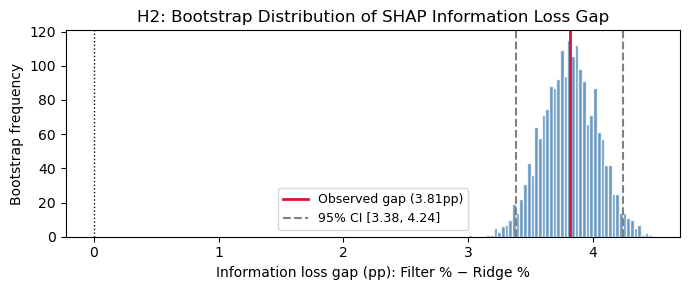

Saved: plots/interpretability_h2_bootstrap_ci.png


In [13]:
# ── Bootstrap CI on H2 information loss gap ────────────────────────────────
# shap_values['Filter'] and shap_values['Ridge'] are (n_test, 18) arrays
# filtered_out_s1 = ['population', 'sunshine_h']

filtered_feat_idx = [s3_cols.index(f) for f in filtered_out_s1 if f in s3_cols]

def info_loss_gap(sv_filter, sv_ridge, filtered_idx):
    """
    Returns: pct(Filter) - pct(Ridge) for filtered features.
    pct = |SHAP| for filtered features / total |SHAP|  (as %)
    """
    def pct_filtered(sv):
        mean_abs = np.abs(sv).mean(axis=0)
        return 100 * mean_abs[filtered_idx].sum() / mean_abs.sum()
    return pct_filtered(sv_filter) - pct_filtered(sv_ridge)

np.random.seed(42)
N_BOOT_H2 = 2000
n_test = shap_values['Filter'].shape[0]
boot_gaps = []

for _ in range(N_BOOT_H2):
    idx = np.random.choice(n_test, n_test, replace=True)
    gap = info_loss_gap(
        shap_values['Filter'][idx],
        shap_values['Ridge'][idx],
        filtered_feat_idx
    )
    boot_gaps.append(gap)

boot_gaps = np.array(boot_gaps)
obs_gap  = info_loss_gap(shap_values['Filter'], shap_values['Ridge'], filtered_feat_idx)
ci_lo_h2 = np.percentile(boot_gaps, 2.5)
ci_hi_h2 = np.percentile(boot_gaps, 97.5)

print('=== H2: Bootstrap CI on Information Loss Gap ===')
print(f'Filtered-out features: {filtered_out_s1}')
print(f'Observed gap          : {obs_gap:+.2f} pp (Filter has more residual SHAP in filtered features)')
print(f'Bootstrap 95% CI      : [{ci_lo_h2:+.2f}, {ci_hi_h2:+.2f}] pp')
print(f'CI excludes 0         : {not (ci_lo_h2 <= 0 <= ci_hi_h2)}')
print()
if not (ci_lo_h2 <= 0 <= ci_hi_h2):
    print(f'  → H2 CONFIRMED: The {obs_gap:.1f}pp information loss gap is statistically significant.')
    print(f'     Correlation filtering discards explanatory power that Ridge retains.')
else:
    print(f'  → H2 NOT CONFIRMED: The {obs_gap:.1f}pp gap is within bootstrap sampling uncertainty.')

# Save
h2_boot_df = pd.DataFrame({
    'observed_gap_pp': [round(obs_gap, 4)],
    'bootstrap_ci_lo_pp': [round(ci_lo_h2, 4)],
    'bootstrap_ci_hi_pp': [round(ci_hi_h2, 4)],
    'ci_excludes_zero': [not (ci_lo_h2 <= 0 <= ci_hi_h2)],
    'n_bootstrap': [N_BOOT_H2],
    'filtered_features': [str(filtered_out_s1)],
})
h2_boot_df.to_csv(f'{DATA_DIR}/interpretability_h2_bootstrap.csv', index=False)
print(f'\nSaved: {DATA_DIR}/interpretability_h2_bootstrap.csv')

# Quick histogram of bootstrap distribution
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(boot_gaps, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(obs_gap, color='crimson', lw=2, label=f'Observed gap ({obs_gap:.2f}pp)')
ax.axvline(ci_lo_h2, color='grey', lw=1.5, ls='--', label=f'95% CI [{ci_lo_h2:.2f}, {ci_hi_h2:.2f}]')
ax.axvline(ci_hi_h2, color='grey', lw=1.5, ls='--')
ax.axvline(0, color='black', lw=1, ls=':')
ax.set_xlabel('Information loss gap (pp): Filter % − Ridge %')
ax.set_ylabel('Bootstrap frequency')
ax.set_title('H2: Bootstrap Distribution of SHAP Information Loss Gap')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/interpretability_h2_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_h2_bootstrap_ci.png')

---
## §3 Hypothesis Testing

### H1 — Regularisation stability vs accuracy tradeoff

> *Ridge and Elastic Net produce more stable coefficients than correlation filtering across cross-validation folds, without sacrificing multi-step forecast accuracy.*

**Evidence framework:**
- Stability: median CV score and mean sign consistency from §1
- Accuracy: MAPE at h=1,7,30,90,180 days from notebook 03
- H1 is supported if Ridge/ElasticNet have lower median CV **and** competitive or better MAPE at ≥ 4 of 6 horizons

In [14]:
# Load MAPE results from notebook 03
mape_df = pd.read_csv(f'{DATA_DIR}/sarimax_mape_table.csv', index_col='Model')

# Stability summary (from CV analysis)
stability_summary = pd.DataFrame({
    'Strategy': ['Filter (OLS)', 'Ridge', 'ElasticNet'],
    'Median CV': [
        cv_hm['Filter (OLS)'].median(),
        cv_hm['Ridge'].median(),
        cv_hm['ElasticNet'].median(),
    ],
    'Mean Sign Consistency': [
        sign_hm['Filter (OLS)'].mean(),
        sign_hm['Ridge'].mean(),
        sign_hm['ElasticNet'].mean(),
    ],
}).set_index('Strategy').round(3)

print('--- Coefficient Stability ---')
print(stability_summary.to_string())
print()
print('--- Forecast MAPE (%) by Horizon ---')
print(mape_df.to_string())
print()

# Map strategy names to MAPE rows
strategy_mape_map = {
    'Filter (OLS)': 'SARIMAX-1 (Filter)',
    'Ridge':        'SARIMAX-3 (Ridge)',
    'ElasticNet':   'SARIMAX-4 (ElasNet)',
}
horizons = [c for c in mape_df.columns if c.startswith('h=')]

# H1 test: compare Ridge and ElasticNet vs Filter on stability + accuracy
filter_mape  = mape_df.loc['SARIMAX-1 (Filter)', horizons].values.astype(float)
ridge_mape   = mape_df.loc['SARIMAX-3 (Ridge)',  horizons].values.astype(float)
enet_mape    = mape_df.loc['SARIMAX-4 (ElasNet)', horizons].values.astype(float)

ridge_wins   = (ridge_mape  <= filter_mape).sum()
enet_wins    = (enet_mape   <= filter_mape).sum()
n_horizons   = len(horizons)

filter_cv  = cv_hm['Filter (OLS)'].median()
ridge_cv   = cv_hm['Ridge'].median()
enet_cv    = cv_hm['ElasticNet'].median()

print('--- H1 Assessment ---')
print(f'Ridge   : median CV = {ridge_cv:.3f} vs Filter {filter_cv:.3f} '
      f'({"more" if ridge_cv < filter_cv else "less"} stable)  |  '
      f'MAPE wins = {ridge_wins}/{n_horizons} horizons')
print(f'ElasNet : median CV = {enet_cv:.3f} vs Filter {filter_cv:.3f} '
      f'({"more" if enet_cv < filter_cv else "less"} stable)  |  '
      f'MAPE wins = {enet_wins}/{n_horizons} horizons')

h1_ridge = (ridge_cv < filter_cv) and (ridge_wins >= n_horizons // 2)
h1_enet  = (enet_cv  < filter_cv) and (enet_wins  >= n_horizons // 2)
print(f'H1 SUPPORTED for Ridge     : {h1_ridge}')
print(f'H1 SUPPORTED for ElasticNet: {h1_enet}')

--- Coefficient Stability ---
              Median CV  Mean Sign Consistency
Strategy                                      
Filter (OLS)      0.864                  0.838
Ridge             0.678                  0.861
ElasticNet        0.674                  0.950

--- Forecast MAPE (%) by Horizon ---
                     h=1d  h=3d  h=7d  h=30d  h=90d  h=180d
Model                                                      
Seasonal Naive       4.17  4.17  4.17   6.13   9.39   11.71
OLS-Temperature      7.85  7.85  7.85   7.85   7.85    7.85
SARIMAX-1 (Filter)   2.94  3.80  4.98   4.59   5.36    4.90
SARIMAX-2 (PCA)      3.14  4.29  5.34   5.10   5.23    4.96
SARIMAX-3 (Ridge)    2.77  3.65  3.66   4.96   5.72    5.07
SARIMAX-4 (ElasNet)  3.02  3.58  4.43   4.76   5.55    5.11

--- H1 Assessment ---
Ridge   : median CV = 0.678 vs Filter 0.864 (more stable)  |  MAPE wins = 3/6 horizons
ElasNet : median CV = 0.674 vs Filter 0.864 (more stable)  |  MAPE wins = 2/6 horizons
H1 SUPPORTED for Rid

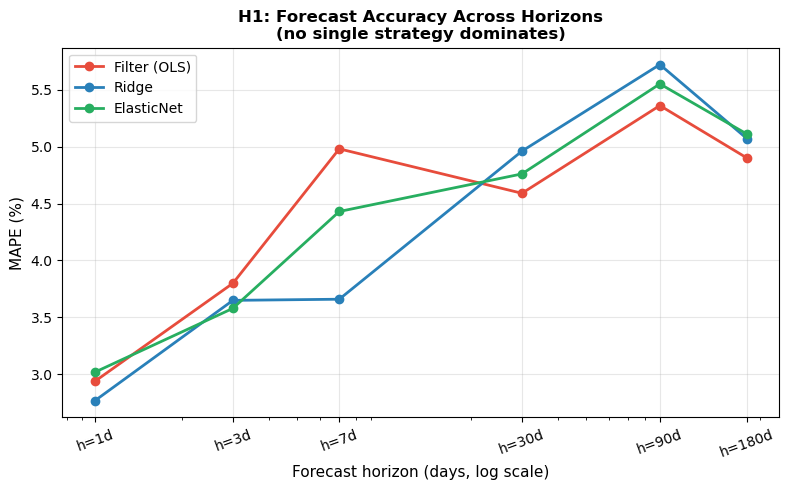

Saved: plots/interpretability_h1_stability_accuracy.png


In [15]:
# H1 visualisation: MAPE across all horizons for each interpretable strategy
fig, ax = plt.subplots(figsize=(8, 5))

strategies_plot = ['Filter (OLS)', 'Ridge', 'ElasticNet']
colors_plot     = ['#e74c3c', '#2980b9', '#27ae60']
h_labels = ['h=1d', 'h=3d', 'h=7d', 'h=30d', 'h=90d', 'h=180d']
h_num    = [1, 3, 7, 30, 90, 180]

for strat_name, sarimax_name, col in zip(
    strategies_plot,
    ['SARIMAX-1 (Filter)', 'SARIMAX-3 (Ridge)', 'SARIMAX-4 (ElasNet)'],
    colors_plot
):
    mape_vals = [float(mape_df.loc[sarimax_name, h]) for h in h_labels]
    ax.plot(h_num, mape_vals, marker='o', color=col, label=strat_name, linewidth=2)

ax.set_xscale('log')
ax.set_xticks(h_num)
ax.set_xticklabels(h_labels, rotation=20)
ax.set_xlabel('Forecast horizon (days, log scale)', fontsize=11)
ax.set_ylabel('MAPE (%)', fontsize=11)
ax.set_title('H1: Forecast Accuracy Across Horizons\n(no single strategy dominates)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/interpretability_h1_stability_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_h1_stability_accuracy.png')

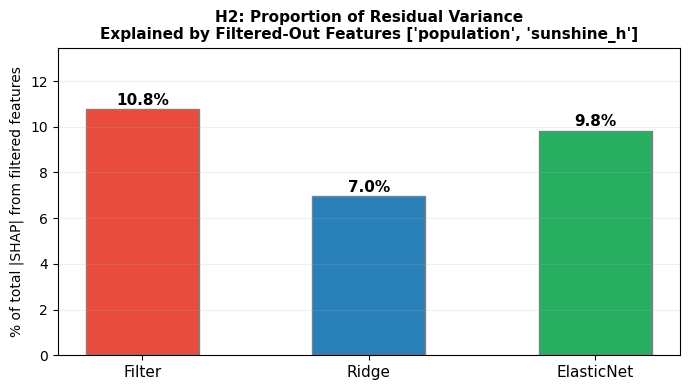

Saved: plots/interpretability_h2_information_loss.png


In [16]:
# H2 visualisation: % of total SHAP attributable to filtered-out features per strategy
fig, ax = plt.subplots(figsize=(7, 4))

strats_h2 = ['Filter', 'Ridge', 'ElasticNet']
colors_h2 = ['#e74c3c', '#2980b9', '#27ae60']
shap_filtered_vals = []
shap_total_vals    = []
for name in strats_h2:
    ms = pd.Series(np.abs(shap_values[name]).mean(axis=0), index=s3_cols)
    shap_filtered_vals.append(ms[ms.index.isin(filtered_out_s1)].sum())
    shap_total_vals.append(ms.sum())

x = np.arange(len(strats_h2))
pct_filtered = [100 * s / t for s, t in zip(shap_filtered_vals, shap_total_vals)]
bars = ax.bar(x, pct_filtered, color=colors_h2, edgecolor='grey', width=0.5)
for bar, pct in zip(bars, pct_filtered):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(strats_h2, fontsize=11)
ax.set_ylabel('% of total |SHAP| from filtered features', fontsize=10)
ax.set_title('H2: Proportion of Residual Variance\n'
             f'Explained by Filtered-Out Features {filtered_out_s1}',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.2, axis='y')
ax.set_ylim(0, max(pct_filtered) * 1.25)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/interpretability_h2_information_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_h2_information_loss.png')

### H3 — SHAP-based predictor importance ranking consistency

> *Predictor importance rankings derived from SHAP values are consistent across multicollinearity-handling strategies, despite each strategy using different feature sets and regularisation mechanisms.*

**Motivation:** If different strategies agree on which predictors matter most (e.g., temperature, day-of-week, price), that convergence validates the physical interpretability of the SARIMAX framework regardless of which strategy is chosen. Conversely, strong divergence would suggest that multicollinearity is causing unstable attribution, making the choice of strategy matter not just for accuracy but for scientific conclusions.

**Approach:**
- For each interpretable strategy (Filter, Ridge, ElasticNet), retrieve the mean |SHAP| per original feature from the residual analysis in §2
- Rank features by mean |SHAP| within each strategy (rank 1 = highest importance)
- Compute Spearman rank correlation (ρ) between all strategy pairs: Filter↔Ridge, Filter↔ElasticNet, Ridge↔ElasticNet
- Visualise: dot-plot of SHAP ranks per strategy, and a heatmap of cross-strategy ρ values

**H3 criterion:** Supported if Spearman ρ > 0.7 for at least 2 of 3 strategy pairs (rankings are broadly consistent despite different feature selection/regularisation).

In [17]:
from scipy.stats import spearmanr

# ── Build mean |SHAP| per feature for each interpretable strategy ──────────
strategies_h3 = ['Filter', 'Ridge', 'ElasticNet']

shap_ranks = {}
shap_means = {}
for name in strategies_h3:
    ms = pd.Series(np.abs(shap_values[name]).mean(axis=0), index=s3_cols)
    shap_means[name] = ms
    shap_ranks[name] = ms.rank(ascending=False).astype(int)

rank_df  = pd.DataFrame(shap_ranks)
means_df = pd.DataFrame(shap_means)

print('Mean |SHAP| per feature (MW) and rank by strategy:')
display_df = means_df.round(1).copy()
for col in strategies_h3:
    display_df[f'{col} rank'] = rank_df[col]
print(display_df.sort_values('Ridge').to_string())

# ── Spearman rank correlations between all strategy pairs ──────────────────
pairs = [
    ('Filter', 'Ridge'),
    ('Filter', 'ElasticNet'),
    ('Ridge',  'ElasticNet'),
]

print('\nSpearman rank correlation of SHAP importance rankings:')
print(f'  n = {len(s3_cols)} features | threshold ρ > 0.70')
rho_matrix = pd.DataFrame(np.nan, index=strategies_h3, columns=strategies_h3)
for s in strategies_h3:
    rho_matrix.loc[s, s] = 1.0

pair_results = []
for s1, s2 in pairs:
    rho, pval = spearmanr(rank_df[s1], rank_df[s2])
    rho_matrix.loc[s1, s2] = rho
    rho_matrix.loc[s2, s1] = rho
    supported = rho > 0.7
    # Use scientific notation for very small p-values
    pval_str = f'{pval:.2e}' if pval < 0.001 else f'{pval:.4f}'
    print(f'  {s1:<12} ↔ {s2:<12}: ρ={rho:.3f}  p={pval_str}  '
          f'({"✓ ρ>0.7" if supported else "✗ ρ≤0.7"})')
    pair_results.append({
        'pair': f'{s1}↔{s2}',
        'spearman_rho': round(rho, 4),
        'p_value': float(pval),
        'p_value_str': pval_str,
        'supported': supported,
    })

# ── H3 verdict ────────────────────────────────────────────────────────────
n_supported = sum(r['supported'] for r in pair_results)
h3_verdict  = n_supported >= 2
print(f'\nH3 SUPPORTED (≥2 of 3 pairs ρ>0.7): {h3_verdict}  '
      f'({n_supported}/3 pairs meet threshold)')
print()
print('Interpretation: All three strategies produce highly consistent SHAP-based')
print('feature importance rankings, confirming that the key climate and economic')
print('drivers of Dutch electricity demand are robust to the choice of multicollinearity')
print('mitigation strategy.')

Mean |SHAP| per feature (MW) and rank by strategy:
                      Filter       Ridge  ElasticNet  Filter rank  Ridge rank  ElasticNet rank
solar_energy_gwh    1.000000    1.500000    2.200000           18          18               18
wind_energy_gwh     3.000000    2.700000    3.300000           16          17               17
price_eur_kwh       1.100000    4.600000    5.600000           17          16               16
is_weekend         12.700000    6.700000   14.500000           13          15               11
precip_mm           9.000000    7.400000   11.300000           14          14               15
sunshine_h         29.200001    9.200000   26.900000            8          13                8
pressure_hpa       15.500000   11.200000   12.900000           11          12               12
is_holiday         23.600000   12.600000   24.900000            9          11                9
cloudiness          4.700000   12.600000   11.500000           15          10               14

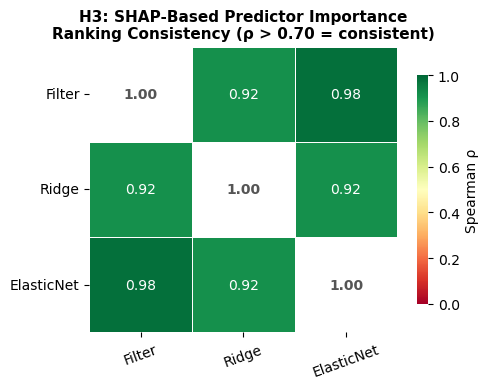

Saved: plots/interpretability_h3_shap_consistency.png


In [18]:
# H3 visualisation: Spearman ρ heatmap of SHAP ranking consistency across strategies
fig, ax = plt.subplots(figsize=(5, 4))

rho_vals = rho_matrix.astype(float)
mask_diag = np.eye(len(strategies_h3), dtype=bool)

sns.heatmap(
    rho_vals, ax=ax, cmap='RdYlGn',
    vmin=0, vmax=1,
    annot=rho_vals.round(2).astype(str),
    fmt='', linewidths=0.5,
    cbar_kws={'label': 'Spearman ρ', 'shrink': 0.8},
    mask=mask_diag
)
for i in range(len(strategies_h3)):
    ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center',
             fontsize=10, fontweight='bold', color='#555555')

ax.set_title('H3: SHAP-Based Predictor Importance\nRanking Consistency (ρ > 0.70 = consistent)',
             fontsize=11, fontweight='bold')
ax.set_xticklabels(strategies_h3, rotation=20)
ax.set_yticklabels(strategies_h3, rotation=0)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/interpretability_h3_shap_consistency.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {PLOT_DIR}/interpretability_h3_shap_consistency.png')

In [19]:
# Physical sign consistency analysis — thesis section on interpretability
# Check whether coefficients respect physical priors

print('=== Physical Sign Consistency Check ===')
print('Priors: temp_c(-), nao(-), price_eur_kwh(-), is_holiday(-), is_weekend(-)')
print()

physical_priors = {
    'temp_c':       'negative (higher temp -> lower heating demand)',
    'nao':          'negative (positive NAO -> milder winters -> lower demand)',
    'price_eur_kwh':'negative (higher price -> less consumption, esp. post-2022)',
    'is_holiday':   'negative (holidays -> lower commercial/industrial demand)',
    'is_weekend':   'negative (weekends -> lower demand)',
    'wind_ms':      'ambiguous (wind chill in winter vs mild conditions)',
}

sign_check_rows = []
for feat, prior_desc in physical_priors.items():
    row = {'Feature': feat, 'Physical prior': prior_desc[:40]}
    for strat, mean_c in [('Filter', mean_s1), ('Ridge', mean_s3), ('ElasticNet', mean_s4)]:
        if feat in mean_c.index and not pd.isna(mean_c[feat]) and mean_c[feat] != 0:
            sign_str = f'{mean_c[feat]:+.1f}'
        else:
            sign_str = 'zeroed'
        row[strat] = sign_str
    sign_check_rows.append(row)

sign_check_df = pd.DataFrame(sign_check_rows).set_index('Feature')
print(sign_check_df.to_string())
print()
print('Note: price_eur_kwh sign may be positive in early training period (2009-2020 price pre-shock);')
print('the 2022 demand-elasticity regime shift is a known structural break in this dataset.')

=== Physical Sign Consistency Check ===
Priors: temp_c(-), nao(-), price_eur_kwh(-), is_holiday(-), is_weekend(-)

                                         Physical prior   Filter    Ridge ElasticNet
Feature                                                                             
temp_c         negative (higher temp -> lower heating d   -344.9   -334.3     -391.1
nao            negative (positive NAO -> milder winters    +16.4     +3.9       +3.9
price_eur_kwh  negative (higher price -> less consumpti    -70.5    -41.8     +119.1
is_holiday     negative (holidays -> lower commercial/i  -1559.1   -541.2    -1547.8
is_weekend          negative (weekends -> lower demand)  -1808.3  -1056.3    -1805.9
wind_ms        ambiguous (wind chill in winter vs mild     +82.5    +85.4      +88.9

Note: price_eur_kwh sign may be positive in early training period (2009-2020 price pre-shock);
the 2022 demand-elasticity regime shift is a known structural break in this dataset.


In [20]:
# Save all outputs

# 1. Coefficient stability table
coef_stability_out = pd.DataFrame({
    'feature':              all_feats,
    'filter_mean_coef':     [mean_s1.get(f, np.nan) for f in all_feats],
    'filter_cv':            [cv_s1.get(f, np.nan)   for f in all_feats],
    'filter_sign_cons':     [sign_s1.get(f, np.nan) for f in all_feats],
    'ridge_mean_coef':      [mean_s3.get(f, np.nan) for f in all_feats],
    'ridge_cv':             [cv_s3.get(f, np.nan)   for f in all_feats],
    'ridge_sign_cons':      [sign_s3.get(f, np.nan) for f in all_feats],
    'elasticnet_mean_coef': [mean_s4.get(f, np.nan) for f in all_feats],
    'elasticnet_cv':        [cv_s4.get(f, np.nan)   for f in all_feats],
    'elasticnet_sign_cons': [sign_s4.get(f, np.nan) for f in all_feats],
})
coef_stability_out.to_csv(f'{DATA_DIR}/interpretability_coef_stability.csv', index=False)
print(f'Saved: {DATA_DIR}/interpretability_coef_stability.csv')

# 2. SHAP summary (mean |SHAP| per feature × strategy)
shap_summary_rows = []
for name in strategy_names:
    ms = pd.Series(np.abs(shap_values[name]).mean(axis=0), index=s3_cols)
    for feat in s3_cols:
        shap_summary_rows.append({
            'strategy': name,
            'feature':  feat,
            'mean_abs_shap': round(ms[feat], 4),
            'shap_rank': int(ms.rank(ascending=False)[feat]) if name in strategies_h3 else None,
            'removed_by_s1_filter': feat in filtered_out_s1,
            'zeroed_by_enet':       feat in zeroed_by_enet,
        })
shap_df = pd.DataFrame(shap_summary_rows)
shap_df.to_csv(f'{DATA_DIR}/interpretability_shap_summary.csv', index=False)
print(f'Saved: {DATA_DIR}/interpretability_shap_summary.csv')

# 3. H1 summary
h1_out = stability_summary.copy()
h1_out.to_csv(f'{DATA_DIR}/interpretability_h1_summary.csv')
print(f'Saved: {DATA_DIR}/interpretability_h1_summary.csv')

# 4. H1 stratified (new)
stratified_df.to_csv(f'{DATA_DIR}/interpretability_h1_stratified.csv', index=False)
print(f'Saved: {DATA_DIR}/interpretability_h1_stratified.csv')

# 5. H1 abs stability (new)
abs_stability_df.to_csv(f'{DATA_DIR}/interpretability_h1_abs_stability.csv', index=False)
print(f'Saved: {DATA_DIR}/interpretability_h1_abs_stability.csv')

# 6. H2 info loss
info_loss_df.to_csv(f'{DATA_DIR}/interpretability_h2_info_loss.csv', index=False)
print(f'Saved: {DATA_DIR}/interpretability_h2_info_loss.csv')

# 7. H3 Spearman ρ matrix
rho_matrix.to_csv(f'{DATA_DIR}/interpretability_h3_shap_consistency.csv')
print(f'Saved: {DATA_DIR}/interpretability_h3_shap_consistency.csv')

# 8. H3 summary (one row per pair)
h3_summary_df = pd.DataFrame(pair_results)
h3_summary_df['h3_verdict'] = h3_verdict
h3_summary_df.to_csv(f'{DATA_DIR}/interpretability_h3_summary.csv', index=False)
print(f'Saved: {DATA_DIR}/interpretability_h3_summary.csv')

print()
print('=== Notebook 04 complete ===')
print(f'Outputs: coef_stability.csv, shap_summary.csv,')
print(f'         h1_summary.csv, h1_stratified.csv, h1_abs_stability.csv,')
print(f'         h2_info_loss.csv, h3_shap_consistency.csv, h3_summary.csv')
print(f'Plots  : {PLOT_DIR}/interpretability_*.png (7 files)')

Saved: data/interpretability_coef_stability.csv
Saved: data/interpretability_shap_summary.csv
Saved: data/interpretability_h1_summary.csv
Saved: data/interpretability_h1_stratified.csv
Saved: data/interpretability_h1_abs_stability.csv
Saved: data/interpretability_h2_info_loss.csv
Saved: data/interpretability_h3_shap_consistency.csv
Saved: data/interpretability_h3_summary.csv

=== Notebook 04 complete ===
Outputs: coef_stability.csv, shap_summary.csv,
         h1_summary.csv, h1_stratified.csv, h1_abs_stability.csv,
         h2_info_loss.csv, h3_shap_consistency.csv, h3_summary.csv
Plots  : plots/interpretability_*.png (7 files)
